## EDA LAB

The General Social Survey (GSS) is a bi-annual nationally representative survey of Americans, with almost 7000 different questions asked since the survey began in the 1970s. It has straightforward questions about respondents' demographic information, but also questions like "Does your job regularly require you to perform repetitive or forceful hand movements or involve awkward postures?" or "How often do the demands of your job interfere with your family life?" There are a variety of controversial questions. No matter what you're curious about, there's something interesting in here to check out. The codebook is 904 pages (use CTRL+F to search it).

The data and codebook are available at:
https://gss.norc.org/us/en/gss/get-the-data.html

The datasets are so large that it might make sense to pick the variables you want, and then download just those variables from:
https://gssdataexplorer.norc.org/variables/vfilter

Here is your task:
1. Download a small (5-15) set of variables of interest.
2. Write a short description of the data you chose, and why. (1 page)
3. Load the data using Pandas. Clean them up for EDA. Do this in a notebook with comments or markdown chunks explaining your choices.
4. Produce some numeric summaries and visualizations. (1-3 pages)
5. Describe your findings in 1-2 pages.
6. If you have other content that you think absolutely must be included, you can include it in an appendix of any length.

For example, you might want to look at how aspects of a person's childhood family are correlated or not with their career or family choices as an adult. Or how political or religious affiliations correlate with drug use or sexual practices. It's an extremely wide-ranging survey.

Feel free to work with other people in groups, and ask questions!

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('GSS2.csv')

<ipython-input-4-f3dcdc5311a0>:1: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('GSS2.csv')


In [5]:
df = df.dropna()

In [6]:
df.isna().sum()

,0
year,0
id_,0
hrs2,0
age,0
educ,0
race,0
socbar,0
rank,0
usetech,0
intwkdyh,0


I decided to select these variables to examine because I wanted to explore if there were any correlations between how much a person used the internet, how much they worked, and how often they spent in a social scene like the bar. I also downloaded some basic variables like year, age, race, and education. I ended up filtering the year to just be 2016, since that was the only year they recorded the intwkdyh and intwkenh variables, which are internet hours per week and internet hours per weekend.

I think there will probably be correlations between age and internet use. I also think there could be negative correlations between hours worked and socbar (hours at a bar) and also socbar and internet use. Presumably, people who spend more time on the internet or more time working might not spend as much time socializing at the bar.

Another variable I downloaded was rank, which is where people ranked their "status" from 1 to 10, 1 being the top and 10 being the bottom. I wasn't sure how this would effect the variables like internet use and time spent at a bar, but I thought it might be interesting to check.

In [7]:
df.head()

,year,id_,hrs2,age,educ,race,socbar,rank,usetech,intwkdyh,intwkenh
0,1972,1,.i: Inapplicable,23,4 years of college,White,.n: No answer,.i: Inapplicable,-100.0,.i: Inapplicable,.i: Inapplicable
1,1972,2,.i: Inapplicable,70,10th grade,White,.n: No answer,.i: Inapplicable,-100.0,.i: Inapplicable,.i: Inapplicable
2,1972,3,.i: Inapplicable,48,12th grade,White,.n: No answer,.i: Inapplicable,-100.0,.i: Inapplicable,.i: Inapplicable
3,1972,4,.i: Inapplicable,27,5 years of college,White,.n: No answer,.i: Inapplicable,-100.0,.i: Inapplicable,.i: Inapplicable
4,1972,5,.i: Inapplicable,61,12th grade,White,.n: No answer,.i: Inapplicable,-100.0,.i: Inapplicable,.i: Inapplicable


In [8]:

df['year'] = pd.to_numeric(df['year'], errors='coerce')


df = df[(df['year']==2016)]

In [9]:
df.columns

Index(['year', 'id_', 'hrs2', 'age', 'educ', 'race', 'socbar', 'rank',
       'usetech', 'intwkdyh', 'intwkenh'],
      dtype='object')

I got rid of the na values and I also turned the age and hours into numeric values

In [10]:
na_vals = [".i: Inapplicable", ".n: No answer", ".d: Don't know", ".r: Refused"]
df.replace(na_vals, pd.NA, inplace=True)


numeric_cols = ['age', 'usetech', 'intwkdyh', 'intwkenh']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_clean = df.dropna(subset=['usetech', 'age', 'educ', 'race'])

df_clean['educ'] = df_clean['educ'].astype('category')
df_clean['race'] = df_clean['race'].astype('category')
df_clean['socbar'] = df_clean['socbar'].astype('category')


<ipython-input-10-d99af117d133>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(na_vals, pd.NA, inplace=True)
<ipython-input-10-d99af117d133>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.replace(na_vals, pd.NA, inplace=True)
<ipython-input-10-d99af117d133>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd

In [11]:
df['usetech'].unique()

array([-100.])

In [12]:
#usetech wasn't recorded in 2016
df = df.drop(columns=['usetech'])

In [13]:
df.columns

Index(['year', 'id_', 'hrs2', 'age', 'educ', 'race', 'socbar', 'rank',
       'intwkdyh', 'intwkenh'],
      dtype='object')

I combined intwkdyh and intwkenh which are the hours spent on the internet on the weekdays and the weekend to have a total internet hour column.

In [14]:

df_clean['age'] = pd.to_numeric(df_clean['age'], errors='coerce')
df_clean['intwkdyh'] = pd.to_numeric(df_clean['intwkdyh'], errors='coerce')
df_clean['intwkenh'] = pd.to_numeric(df_clean['intwkenh'], errors='coerce')

df_clean['total_internet_hours'] = df_clean['intwkdyh'] + df_clean['intwkenh']

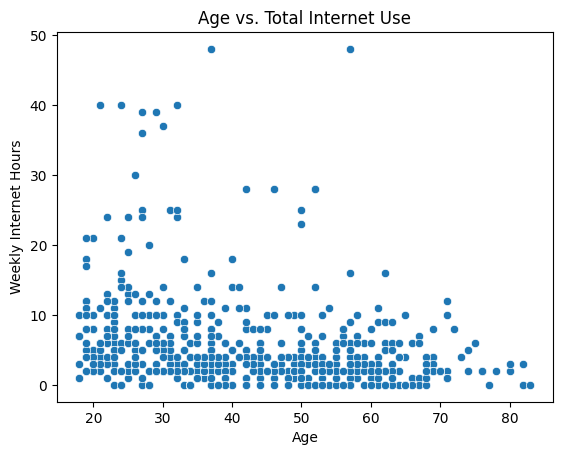

In [27]:

sns.scatterplot(data=df_clean, x='age', y='total_internet_hours')
plt.title("Age vs. Total Internet Use")
plt.xlabel("Age")
plt.ylabel("Weekly Internet Hours")
plt.show()

Here I looked at age versus internet use, and it does show younger people as being more likely to spend more time on the internet but the correlation is not as strong as I expected.

Socbar wasn't a numeric value so I had to clean it

In [16]:
print(df_clean['socbar'].value_counts())

socbar
.n:  No answer                    969
NEVER                             834
ONCE A YEAR                       270
SEV TIMES A YEAR                  252
ONCE A MONTH                      221
SEV TIMES A MNTH                  154
SEV TIMES A WEEK                  117
ALMOST DAILY                       16
.d:  Do not Know/Cannot Choose      1
.s:  Skipped on Web                 1
Name: count, dtype: int64


In [17]:
df_clean = df_clean[~df_clean['socbar'].isin([
    ".n:  No answer", ".d:  Do not Know/Cannot Choose", ".s:  Skipped on Web"
])]

In [18]:
df_clean['socbar'] = df_clean['socbar'].replace({
    "SEV TIMES A MNTH": "SEVERAL TIMES A MONTH",
    "SEV TIMES A YEAR": "SEVERAL TIMES A YEAR",
    "SEV TIMES A WEEK": "SEVERAL TIMES A WEEK"
})

<ipython-input-18-8aa728f5a9d4>:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_clean['socbar'] = df_clean['socbar'].replace({
<ipython-input-18-8aa728f5a9d4>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['socbar'] = df_clean['socbar'].replace({


In [19]:
soc_order = [
    "NEVER",
    "ONCE A YEAR",
    "SEVERAL TIMES A YEAR",
    "ONCE A MONTH",
    "SEVERAL TIMES A MONTH",
    "SEVERAL TIMES A WEEK",
    "ALMOST DAILY"
]

df_clean['socbar'] = pd.Categorical(df_clean['socbar'], categories=soc_order, ordered=True)

<ipython-input-19-28b415c0db6d>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['socbar'] = pd.Categorical(df_clean['socbar'], categories=soc_order, ordered=True)


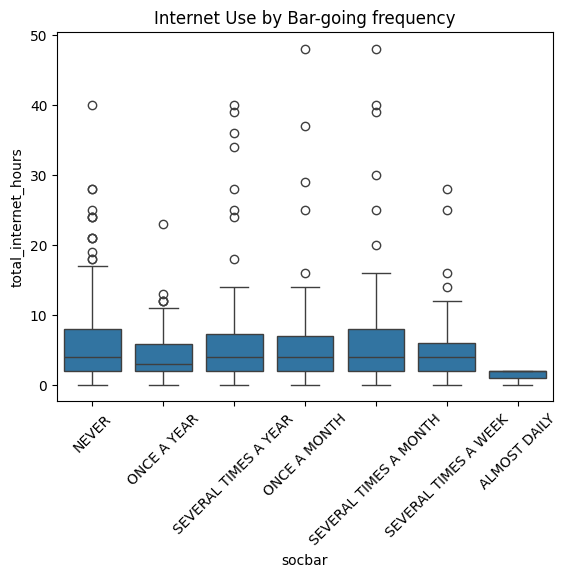

In [20]:
sns.boxplot(data=df_clean, x='socbar', y='total_internet_hours')
plt.title("Internet Use by Bar-going frequency")
plt.xticks(rotation=45)
plt.show()

In [21]:
df_clean.columns

Index(['year', 'id_', 'hrs2', 'age', 'educ', 'race', 'socbar', 'rank',
       'usetech', 'intwkdyh', 'intwkenh', 'total_internet_hours'],
      dtype='object')

In [22]:
df_clean['rank'] = pd.to_numeric(df_clean['rank'], errors='coerce')
df_clean = df_clean[(df_clean['rank'] >= 1) & (df_clean['rank'] <= 10)]


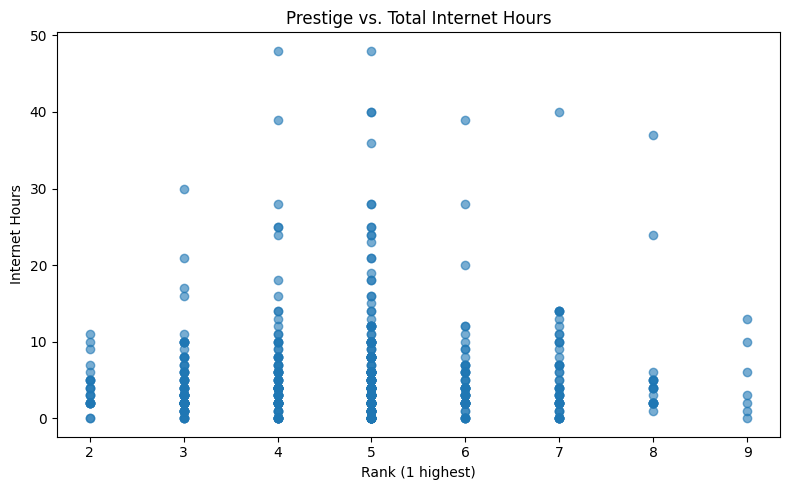

In [23]:
plt.figure(figsize=(8, 5))
plt.scatter(df_clean['rank'], df_clean['total_internet_hours'], alpha=0.6)
plt.title("Prestige vs. Total Internet Hours")
plt.xlabel("Rank (1 highest)")
plt.ylabel("Internet Hours")

plt.tight_layout()
plt.show()

<ipython-input-24-2136409c230d>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_internet_by_soc = df_clean.groupby('socbar')['total_internet_hours'].mean().dropna()


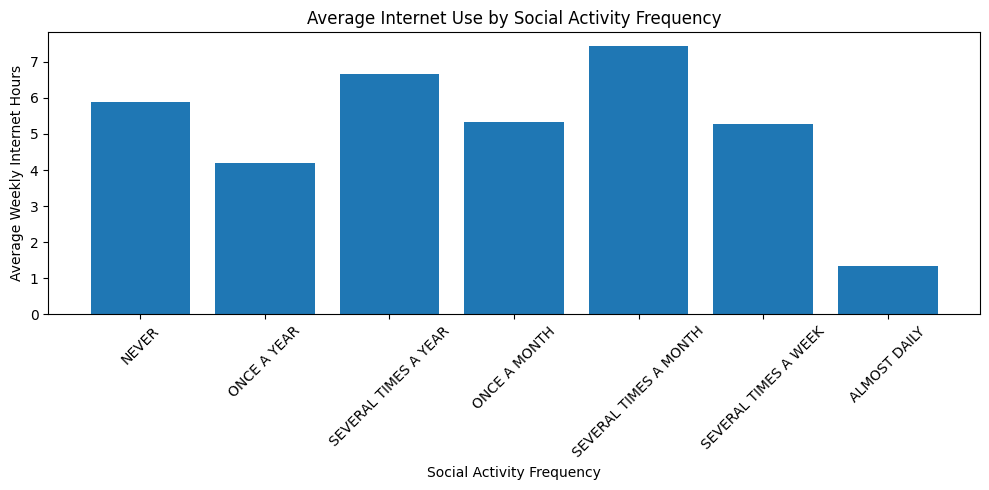

In [24]:
mean_internet_by_soc = df_clean.groupby('socbar')['total_internet_hours'].mean().dropna()

plt.figure(figsize=(10, 5))
plt.bar(mean_internet_by_soc.index, mean_internet_by_soc.values)
plt.title("Average Internet Use by Social Activity Frequency")
plt.xlabel("Social Activity Frequency")
plt.ylabel("Average Weekly Internet Hours")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

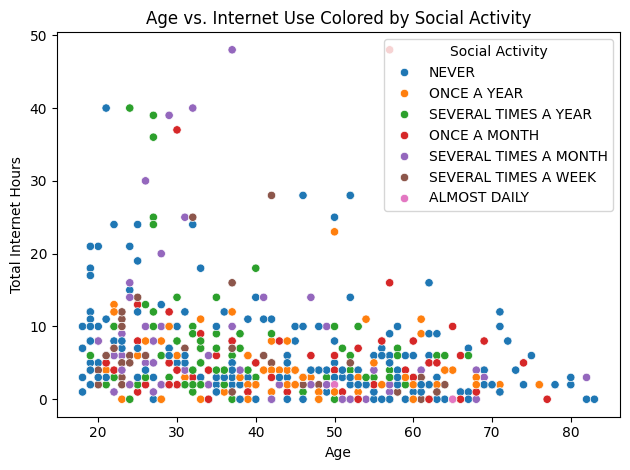

In [25]:
sns.scatterplot(
    data=df_clean,
    x='age',
    y='total_internet_hours',
    hue='socbar'
)
plt.title("Age vs. Internet Use Colored by Social Activity")
plt.xlabel("Age")
plt.ylabel("Total Internet Hours")
plt.legend(title="Social Activity")
plt.tight_layout()
plt.show()

I wanted to explore how age, internet use, bar-going frequency, and social rank interact. I began by examining the relationship between age and internet use and found that younger individuals tend to spend more time online. However, the difference was not dramatic, suggesting that while age may play a role, it is not the sole determinant of internet use.

To investigate social behaviors further, I created a box plot comparing hours of internet use across categories of bar-going frequency. The results showed that individuals who reported going to the bar several times a week or almost daily were less likely to spend many hours online. This trend was especially pronounced among the “almost daily” group, who consistently showed lower internet use. However, the pattern was less clear among the other frequency groups, where internet use varied widely.

To visualize this another way, I used a histogram to see internet use across bar-going categories. This helped clarify the trend for the “almost daily” group but reinforced that no strong or consistent pattern emerged across the other groups.

I wanted to see if social rank influenced these relationships at all, so I examined the distribution of internet hours across rank categories. The distribution appeared fairly normal, suggesting that rank likely does not have a strong effect these facotrs.

I went back to the scatter plot I had created, and color coded it by bar-going frequency. While visually interesting, the colored scatter plot did not reveal any obvious patterns or clusters. There was no clear correlation between bar-going frequency and internet use, nor was it confined to a particular age or rank group.

Overall, my findings suggest that while younger people tend to use the internet more, and those who go to bars almost daily may use it less, these patterns are not as strong or consistent as I originally guessed. So, high internet use and frequently going to bars are not only habits of young people. In fact, there seems to be a lot of variation in all of these relationships. At least in 2016 there was. It would be interesting to check that now and see if some of these correlations are more drastic.
